### Métodos Numéricos Computacionales
#### Prácticas computacionales de "Solución de ecuaciones diferenciales ordinarias"

Instrucciones para los Ejercicios

1. **Trabajo en Grupo:**
   - Los ejercicios deben ser resueltos y entregados en grupo.
   - La cantidad de integrantes por grupo será definida el día de la actividad, así como la fecha límite para la entrega.

2. **Uso de Google Colab y Compartir:**
   - Este notebook debe ser copiado al GitHub o Google Drive de alguno de los integrantes del grupo.
   - El grupo será responsable de programar las soluciones, realizar las pruebas y enviar el trabajo final al profesor.

3. **Implementación de los Ejercicios:**
   - Cada ejercicio debe ser implementado de manera que cumpla con los objetivos específicos descritos en cada problema.
   - El código debe devolver claramente la información calculada de acuerdo a lo solicitado.

4. **Calidad del Código:**
   - El código debe ejecutarse sin errores.
   - Es obligatorio incluir **comentarios explicativos** para describir las ideas y conceptos implícitos en el código, facilitando la comprensión de su lógica.

5. **Envío del Trabajo:**
   - Una vez completado, el notebook debe ser enviado a través de Moodle.
   - En caso de dudas, pueden contactarme por correo electrónico a **marcelo.danesi@utec.edu.uy**.

6. **Orientaciones Adicionales:**
   - Asegúrense de que todas las celdas de código hayan sido ejecutadas antes de enviar.
   - Incluyan el nombre completo y correo electrónico de todos los integrantes al inicio del notebook.
   - Si utilizan referencias externas, menciónenlas de forma adecuada.

¡Buena suerte y aprovechen la práctica para consolidar los conceptos de métodos numéricos!

En esta práctica trabajaremos con problemas de valor inicial (PVI) para ecuaciones diferenciales ordinarias de primer orden de la forma:
$$
y' = f(x, y), \quad y(x_0) = y_0
$$

Este tipo de problemas aparece con frecuencia en modelos físicos, químicos, biológicos y económicos. Como en muchos casos no es posible encontrar soluciones analíticas exactas, recurrimos a técnicas numéricas para obtener aproximaciones.

A lo largo de esta notebook exploraremos los métodos más comunes para resolver PVI:
- Método de Euler.
- Método de Runge-Kutta de cuarto orden (RK4).
- Método de Euler implícito.
- Fórmulas de Diferenciación Regresiva (BDF).

Cada técnica será acompañada por un ejemplo programado, seguido por ejercicios de implementación y comparación de resultados.


#### **Métodos explícitos: Método de Euler**

Es el método más sencillo para aproximar una solución numérica. A partir del valor conocido $y_n$, se calcula el siguiente valor $y_{n+1}$ como:
$$
y_{n+1} = y_n + h f(x_n, y_n)
$$

##### **Ejemplo: Implementación del Método de Euler**

**Descripción del problema:**

Resolver el PVI
$$
\left\{ \begin{array}{l}
y' =  x - y, \\
y(0) = 3.
\end{array} \right.
$$

en el intervalo $x\in [0, 2.5]$ con paso $h = 0.5$.

**Objetivos:**

- Implementar el método de Euler.
- Calcular $y$ en varios puntos.
- Visualizar la trayectoria aproximada.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Función que implementa el método de Euler explícito
def euler(f, x0, y0, h, n):
    x = [x0]      # Lista de valores de x
    y = [y0]      # Lista de valores de y
    for i in range(n):
        y_new = y[-1] + h * f(x[-1], y[-1])  # Aproximación de y en el siguiente paso
        x_new = x[-1] + h                    # Avance en x
        x.append(x_new)
        y.append(y_new)
    return np.array(x), np.array(y)

# Definimos la función del PVI: y' = x - y
f = lambda x, y: x - y

# Ejecutamos la función con condiciones iniciales
x, y = euler(f, 0, 3, 0.5, 5)

# Graficamos el resultado
plt.plot(x, y, 'o-', label='Euler')
plt.title("Método de Euler")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.show()

##### **Ejercicio 1: Primeros pasos con Euler**

**Descripción del problema:**  
Aproxime la solución del siguiente PVI usando el método de Euler con paso $h = 0.2$:
$$
y' = x + y, \quad y(0) = 1.
$$

**Objetivos:**
- Aplicar el método de Euler paso a paso.
- Calcular los valores aproximados de $y$ para $x = 0, 0.2, 0.4, 0.6, 0.8, 1.0$.
- Graficar la solución aproximada.

##### **Ejercicio 2: Comparación con solución exacta**

**Descripción del problema:**  
Considere el PVI:
$$
y' = x - 2y, \quad y(0) = 1.
$$
Use el método de Euler con $h = 0.1$ hasta $x = 1$.

**Objetivos:**
- Comparar la solución numérica con la solución analítica $y(x) = \frac{1}{4}(2x - 1 +5e^{-2x})$.
- Graficar ambas soluciones.
- Calcular el error absoluto en cada punto.


##### **Ejercicio 3: Error en función del paso**

**Descripción del problema:**  
Resuelva numéricamente el siguiente PVI:
$$
y' = y - x^2 + 1, \quad y(0) = 0.5.
$$

**Objetivos:**
- Ejecutar el método de Euler con distintos valores de $h: 0.4, 0.2, 0.1, 0.05$ hasta $x = 2$.
- Comparar con la solución exacta $y(x) = (x + 1)^2 - 0.5e^x$.
- Graficar el error absoluto en función de $h$.


#### **Métodos explícitos: Método de Runge-Kutta de cuarto orden (RK4)**

Este método mejora la precisión del método de Euler sin requerir pasos muy pequeños. Usa una media ponderada de varias pendientes intermedias para avanzar:


##### **Ejemplo: Implementación del Método de Runge-Kutta de cuarto orden (RK4)**

**Descripción del problema:**

Resolver el mismo PVI anterior
$$
\left\{ \begin{array}{l}
y' =  x - y, \\
y(0) = 3,
\end{array} \right.
$$

con $h = 0.5$ y comparar los resultados con el método de Euler.

**Objetivos:**
- Implementar el método de Runge-Kutta de cuarto orden.
- Calcular la solución numérica.
- Graficar la evolución de la solución.

In [ ]:
# Función que implementa el método RK4
def rk4(f, x0, y0, h, n):
    x = [x0]
    y = [y0]
    for i in range(n):
        k1 = f(x[-1], y[-1])
        k2 = f(x[-1] + h/2, y[-1] + h/2*k1)
        k3 = f(x[-1] + h/2, y[-1] + h/2*k2)
        k4 = f(x[-1] + h, y[-1] + h*k3)
        y_new = y[-1] + h/6*(k1 + 2*k2 + 2*k3 + k4)  # Fórmula de RK4
        x_new = x[-1] + h
        x.append(x_new)
        y.append(y_new)
    return np.array(x), np.array(y)

# Ejecutamos RK4 con el mismo problema
x, y = rk4(f, 0, 3, 0.5, 5)
plt.plot(x, y, 'o-', label='RK4')
plt.title("Método de Runge-Kutta 4")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.show()

##### **Ejercicio 1: Aplicación básica del método RK4**

**Descripción del problema:**  
Resuelva el siguiente PVI usando RK4 con paso $h=0.2$:
$$
y' = x + y, \quad y(0) = 1.
$$

**Objetivos:**
- Implementar RK4 reutilizando la función ya desarrollada.
- Calcular $y$ para $x = 0, 0.2, 0.4, ..., 1.0$.
- Graficar la solución aproximada.

##### **Ejercicio 2: Comparación con método de Euler**

**Descripción del problema:**  
Considere el PVI:
$$
y' = y - x^2 + 1, \quad y(0) = 0.5.
$$

**Objetivos:**
- Comparar las soluciones obtenidas por RK4 y Euler con $h = 0.1$ hasta $x=2$.
- Comparar con la solución exacta $y(x) = (x + 1)^2 - 0.5e^x$.
- Graficar y analizar el error absoluto de cada método.

##### **Ejercicio 3: Aproximación y visualización**

**Descripción del problema:**  
Aproxime la solución del PVI:
$$
y' = \cos(x) - y, \quad y(0) = 0.
$$

**Objetivos:**
- Aplicar RK4 con $h = 0.1$ hasta $x = 3$.
- Graficar la trayectoria numérica.
- Estimar visualmente la convergencia hacia la solución exacta $$y(x) = \frac{1}{2}(\cos(x) + \text{sen}(x) -e^{-x})$$

#### **Métodos adaptativos: Método de Euler implícito**

El método de Euler implícito utiliza la pendiente en el punto siguiente, lo cual aumenta la estabilidad para ciertos problemas.


##### **Ejemplo: Implementación del Método de Euler implícito**

**Descripción del problema:**

Resolver el PVI
$$
\left\{ \begin{array}{l}
y' =  -2y + x, \\
y(1) = 0,
\end{array} \right.
$$
en el intervalo $[1, 2]$ con paso $h = 0.2$.

**Objetivos:**
- Implementar una versión simplificada del método de Euler implícito.
- Resolver analíticamente $y_{n+1}$ para la función dada.


In [1]:
# Función que implementa el método de Euler implícito
# Para esta ecuación específica: y' = -2y + x
# Se puede resolver de forma explícita la fórmula de y_{n+1}
def euler_implicito(f, x0, y0, h, n):
    x = [x0]
    y = [y0]
    for i in range(n):
        xn1 = x[-1] + h
        # Resolución explícita de y_{n+1} para esta función
        y_n1 = (y[-1] + h * xn1) / (1 + 2*h)
        x.append(xn1)
        y.append(y_n1)
    return np.array(x), np.array(y)

f = lambda x, y: -2*y + x
x, y = euler_implicito(f, 1, 0, 0.2, 5)
plt.plot(x, y, 'o-', label='Euler implícito')
plt.title("Euler implícito")
plt.grid()
plt.show()

NameError: name 'np' is not defined

##### **Ejercicio 1: Aplicación directa del método**

**Descripción del problema:**  
Aproxime la solución del siguiente PVI:
$$
y' = -y + 1, \quad y(0) = 0.
$$

**Objetivos:**
- Aplicar Euler implícito con $h = 0.2$ hasta $x = 1.0$.
- Resolver $y_{n+1}$ en cada paso.
- Graficar la evolución de la solución.


##### **Ejercicio 2: Comparación con solución exacta**

**Descripción del problema:**  
Considere el PVI:
$$
y' = -2y + x, \quad y(1) = -1.
$$

**Objetivos:**
- Aplicar Euler implícito con $h = 0.1$ hasta $x = 2$.
- Comparar con la solución exacta $y(x) = \frac{1}{4}(2x -1 - 5e^{-2(x-1)})$.
- Graficar y analizar el error absoluto.

##### **Ejercicio 3: Comparación entre métodos**

**Descripción del problema:**  
Resuelva el siguiente PVI:
$$
y' = -15y + 10, \quad y(0) = 1.
$$

**Objetivos:**
- Aplicar Euler explícito y Euler implícito con $h = 0.1$ hasta $x = 1$.
- Comparar sus trayectorias.

#### **Métodos adaptativos: Fórmulas de Diferenciación Regresiva (BDF)**

Los métodos BDF son útiles para problemas rígidos. Aquí implementamos el método BDF-2 para la ecuación $y' = -2y$.


##### **Ejemplo: Implementación de las Fórmulas de Diferenciación Regresiva (BDF)**

**Descripción del problema:**

Resolver el PVI
$$
\left\{ \begin{array}{l}
y' =  -2y, \\
y(0) = 4,
\end{array} \right.
$$

paso $h=0.25$ hasta $x = 1$.

**Objetivos:**
- Implementar BDF-2 usando una forma explícita.
- Visualizar la aproximación.


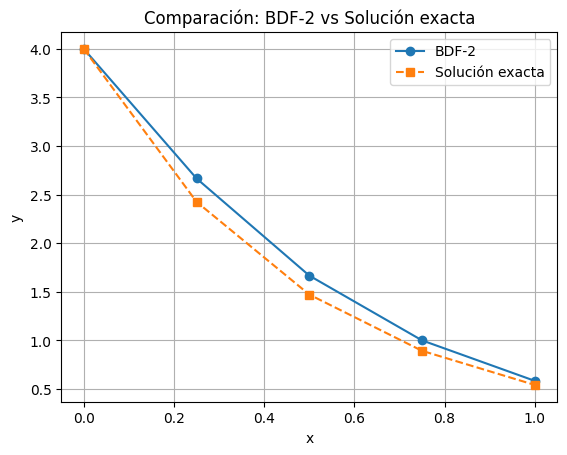

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Implementación del método BDF-2 para y' = -2y
def bdf2(y0, f, h, pasos):
    y = [y0]
    y1 = y0 / (1 + 2*h)  # Paso inicial con Euler implícito
    y.append(y1)
    for n in range(1, pasos):
        yn1 = y[n] - 0.25*y[n-1]  # Forma explícita deducida para esta ecuación
        y.append(yn1)
    return np.array(y)

# Parámetros
h = 0.25
pasos = 4
x = np.linspace(0, h * pasos, pasos + 1)

# Solución numérica
y_bdf2 = bdf2(4, lambda x, y: -2*y, h, pasos)

# Solución exacta
y_exacta = 4 * np.exp(-2 * x)

# Gráfico
plt.plot(x, y_bdf2, 'o-', label='BDF-2')
plt.plot(x, y_exacta, 's--', label='Solución exacta')
plt.title("Comparación: BDF-2 vs Solución exacta")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.legend()
plt.show()


##### **Ejercicio 1: BDF-2 paso a paso**

**Descripción del problema:**
Resuelva el PVI:  
$$
y' = -2y, \quad y(0) = 4.
$$

**Objetivos:**
- Aplicar BDF-2 con $h = 0.25$ hasta $x = 1.0$.
- Comparar con la solución exacta $y(x) = 4e^{-2x}$.
- Graficar la evolución de la solución.


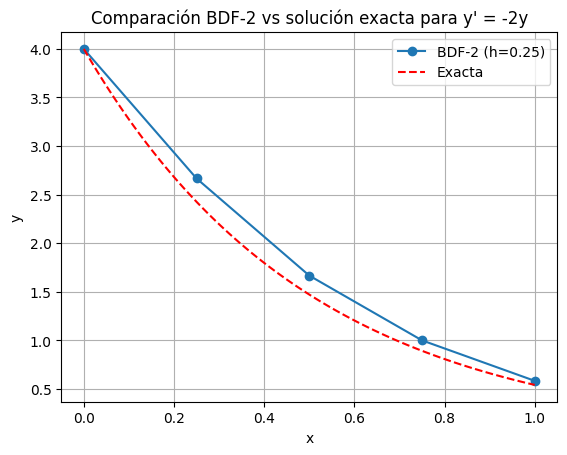

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Euler implícito
def euler_implicito(f, x0, y0, h, tol=1e-10, max_iter=100):
    x1 = x0 + h
    y_old = y0
    for _ in range(max_iter):
        y_new = y0 + h * f(x1, y_old)
        if abs(y_new - y_old) < tol:
            return y_new
        y_old = y_new
    print("Advertencia: Euler implícito no converge")
    return y_old

def bdf2(y0, f, h, pasos):
    x_vals = [x0]
    y_vals = [y0]

    y1 = euler_implicito(f, x0, y0, h)
    x_vals.append(x0 + h)
    y_vals.append(y1)

    for n in range(1, pasos):
        # Usamos fórmula implícita específica para y' = -2y, derivada del BDF-2
        # (3/2h + 2) * y_{n+1} = (2/h) * y_n - (1/2h) * y_{n-1}
        # y_{n+1} = ( (2/h) * y_n - (1/2h) * y_{n-1} ) / (3/2h + 2)

        num = (2/h)*y_vals[n] - (0.5/h)*y_vals[n-1]
        den = (3/(2*h) + 2)
        yn1 = num / den
        y_vals.append(yn1)

    return np.array(y)

def funcion_exacta(x):
    return 4 * np.exp(-2 * x)

def funcion(x, y):
    return -2 * y

# Parámetros
h = 0.25
y0 = 4
x0 = 0
xf = 1

# Puntos para BDF-2
x = np.arange(x0, xf + h, h)
n = len(x) - 1  # n pasos → n+1 puntos

# Aplicar BDF-2
y = bdf2(y0, funcion, h, n)

# Evaluar solución exacta en muchos puntos para suavidad
x_fina = np.linspace(x0, xf, 100)
y_exacta_fina = funcion_exacta(x_fina)

# Graficar
plt.plot(x, y, 'o-', label='BDF-2 (h=0.25)')
plt.plot(x_fina, y_exacta_fina, 'r--', label='Exacta')
plt.title("Comparación BDF-2 vs solución exacta para y' = -2y")
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()
plt.show()


##### **Ejercicio 2: Comparación con RK4**

**Descripción del problema:**  
Considere el PVI:
$$
y' = -50(y - \cos(x)), \quad y(0) = 1.
$$

**Objetivos:**
- Resolver usando BDF-2 y RK4 con $h = 0.05$ hasta $x = 1$.
- Graficar y comparar las trayectorias.

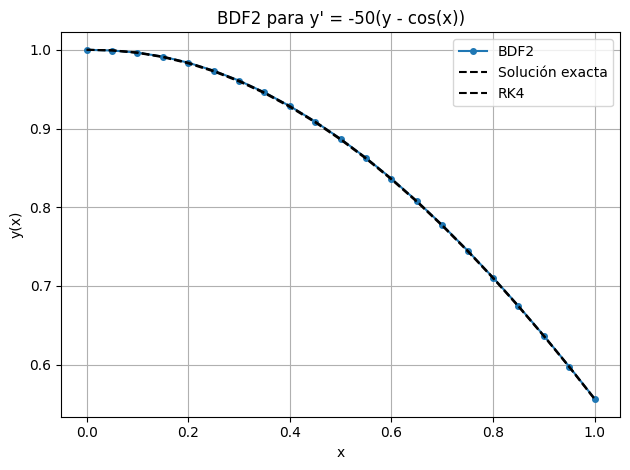

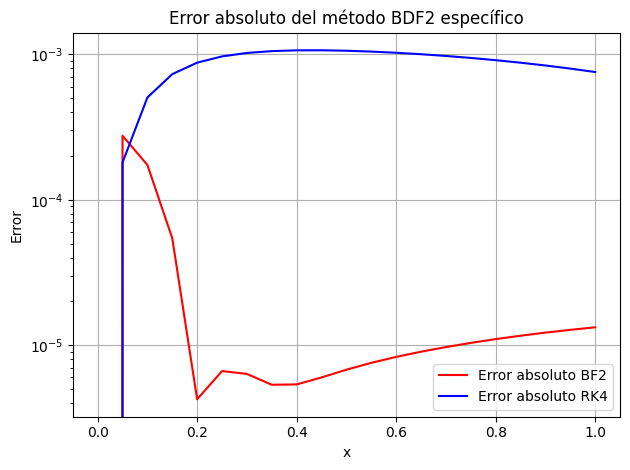

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# EDO específica: y' = -50(y - cos(x))
def f(x, y):
    return -50 * (y - np.cos(x))

# Paso inicial con Euler implícito (solo para el primer paso)
def euler_implicito(x0, y0, h):
    # f(x, y) = -50y + 50cos(x)  → lineal en y
    x1 = x0 + h
    num = y0 + 50 * h * np.cos(x1)
    den = 1 + 50 * h
    return num / den

# BDF2 para y' = -50(y - cos(x))
def bdf2(x0, y0, h, pasos):
    x_vals = [x0]
    y_vals = [y0]

    # Primer paso con Euler implícito
    y1 = euler_implicito(x0, y0, h)
    x1 = x0 + h
    x_vals.append(x1)
    y_vals.append(y1)

    # Pasos siguientes con BDF2
    for n in range(1, pasos):
        x_np1 = x_vals[-1] + h
        y_n = y_vals[-1]
        y_nm1 = y_vals[-2]

        numerador = 4 * y_n - y_nm1 + 100 * h * np.cos(x_np1)
        denominador = 3 + 100 * h
        y_np1 = numerador / denominador

        x_vals.append(x_np1)
        y_vals.append(y_np1)

    return np.array(x_vals), np.array(y_vals)

def rk4(f, x0, y0, h, n):
    x = [x0]
    y = [y0]
    for i in range(n):
        k1 = f(x[-1], y[-1])
        k2 = f(x[-1] + h/2, y[-1] + h/2*k1)
        k3 = f(x[-1] + h/2, y[-1] + h/2*k2)
        k4 = f(x[-1] + h, y[-1] + h*k3)
        y_new = y[-1] + h/6*(k1 + 2*k2 + 2*k3 + k4)  # Fórmula de RK4
        x_new = x[-1] + h
        x.append(x_new)
        y.append(y_new)
    return np.array(x), np.array(y)

# Solución exacta para comparación
def y_exacta(x):
    return (np.exp(-50 * x) + (2500*np.cos(x)) + (50 * np.sin(x)) )/ 2501

# Parámetros
x0 = 0
y0 = 1
h = 0.05
xf = 1
pasos = int((xf - x0) / h)

# Ejecutar BDF2
x_vals, y_bdf2 = bdf2(x0, y0, h, pasos)
x_rk4, y_rk4 = rk4(f,x0, y0, h, pasos)
# Calcular solución exacta
y_ex = y_exacta(x_vals)

# Graficar
plt.plot(x_vals, y_bdf2, 'o-', label='BDF2', markersize=4)
plt.plot(x_vals, y_ex, 'k--', label='Solución exacta')
plt.plot(x_rk4, y_rk4, 'k--', label='RK4')
plt.xlabel("x")
plt.ylabel("y(x)")
plt.title("BDF2 para y' = -50(y - cos(x))")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Graficar error
error = np.abs(y_bdf2 - y_ex)
error_rk4 = np.abs(y_rk4 - y_ex)
plt.plot(x_vals, error, label="Error absoluto BF2", color='red')
plt.plot(x_vals, error_rk4, label="Error absoluto RK4", color='blue')
plt.yscale('log')
plt.xlabel("x")
plt.ylabel("Error")
plt.title("Error absoluto del método BDF2 específico")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



##### **Ejercicio 3: BDF-3 con múltiples pasos**

**Descripción del problema:**  
Resuelva el siguiente PVI:
$$
y' = -2y + 1, \quad y(1) = 0.
$$

**Objetivos:**
- Usar BDF-3 con $h = 0.1$ para calcular $y$ hasta $x = 1.5$.
- Estimar $y(1.5)$ usando pasos consecutivos.
- Graficar la solución aproximada.

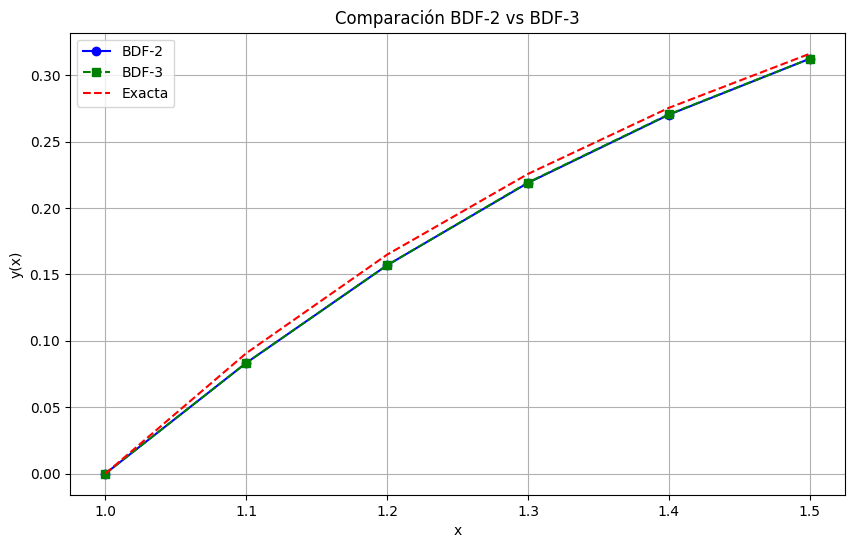

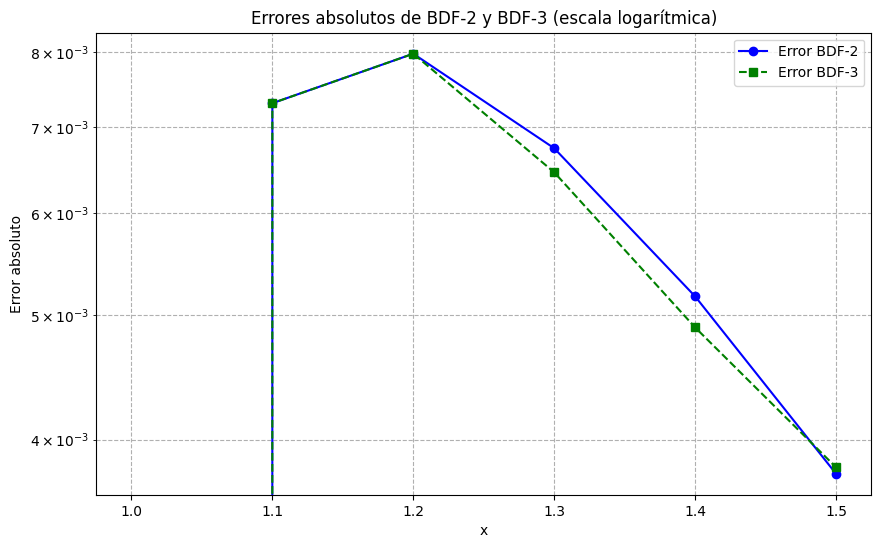

y(1.5) BDF-2: 0.31229770556706293
y(1.5) BDF-3: 0.3122537638332172
y(1.5) Exacta: 0.316060279414279
Error BDF-2 en x=1.5: 0.0037625738472160664
Error BDF-3 en x=1.5: 0.00380651558106182


In [8]:
import numpy as np
import matplotlib.pyplot as plt


# Euler implícito para y' = -2y + 1
def euler_implicito(x0, y0, h):
    x1 = x0 + h
    y1 = (y0 + h) / (1 + 2*h)
    return y1

def f(x, y):
    return -2*y + 1

# BDF-2 general con paso inicial usando Euler implícito
def bdf2(x0, y0, h, pasos):
    x_vals = [x0]
    y_vals = [y0]

    y1 = euler_implicito(x0, y0, h)
    x_vals.append(x0 + h)
    y_vals.append(y1)

    for n in range(1, pasos - 1):
        x_next = x_vals[n] + h
        # Cálculo directo para ecuación lineal
        numerator = (4/3)*y_vals[n] - (1/3)*y_vals[n-1] + (2/3)*h
        denominator = 1 + (4/3)*h
        y_next = numerator / denominator

        y_vals.append(y_next)
        x_vals.append(x_next)

    return np.array(x_vals), np.array(y_vals)



def bdf3(x0, y0, h, pasos):

    x_vals = [x0]
    y_vals = [y0]

    x2,y2 = bdf2(x0, y0, h, pasos)
    x_vals.append(x2[1])
    y_vals.append(y2[1])   # esto agrega el valor para x1, y1 calculado por euler

    x_vals.append(x2[2])
    y_vals.append(y2[2])   # esto agrega el valor para x2, y2 calculado por bf2

    # BDF-3 directo para pasos >= 3
    for n in range(2, pasos - 1):
        x_next = x_vals[n] + h
        numerator = 3*y_vals[n] - 1.5*y_vals[n-1] + (1/3)*y_vals[n-2] + h
        denominator = (11/6) + 2*h
        y_next = numerator / denominator
        x_vals.append(x_next)
        y_vals.append(y_next)

    return np.array(x_vals), np.array(y_vals)

# Parámetros
h = 0.1
x0 = 1.0
xf = 1.5
y0 = 0
pasos = int((xf - x0) / h) + 1

# Resolver
x2, y2 = bdf2(x0, y0, h, pasos)
x3, y3 = bdf3(x0, y0, h, pasos)

# Solución exacta (para comparar)
y_exacta = 0.5 * (1 - np.exp(-2*(x2 - 1)))

# Gráfica
plt.figure(figsize=(10,6))
plt.plot(x2, y2, 'bo-', label='BDF-2')
plt.plot(x3, y3, 'gs--', label='BDF-3')
plt.plot(x2, y_exacta, 'r--', label='Exacta')
plt.title("Comparación BDF-2 vs BDF-3")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.grid(True)
plt.legend()
plt.show()

# Calcular errores
error_bdf2 = np.abs(y2 - y_exacta)
error_bdf3 = np.abs(y3 - y_exacta)

# Gráfica de errores en escala logarítmica
plt.figure(figsize=(10,6))
plt.plot(x2, error_bdf2, 'bo-', label='Error BDF-2')
plt.plot(x3, error_bdf3, 'gs--', label='Error BDF-3')
plt.yscale('log')
plt.title('Errores absolutos de BDF-2 y BDF-3 (escala logarítmica)')
plt.xlabel('x')
plt.ylabel('Error absoluto')
plt.grid(True, which='both', linestyle='--')
plt.legend()
plt.show()

# Mostrar estimaciones y errores en x = 1.5
print(f"y(1.5) BDF-2: {y2[-1]}")
print(f"y(1.5) BDF-3: {y3[-1]}")
print(f"y(1.5) Exacta: {y_exacta[-1]}")
print(f"Error BDF-2 en x=1.5: {error_bdf2[-1]}")
print(f"Error BDF-3 en x=1.5: {error_bdf3[-1]}")

